In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
%cd /content/drive/MyDrive/College/FLEX-Med/flex-med

/content/drive/MyDrive/College/FLEX-Med/flex-med


In [8]:
!pip install nest-asyncio uvicorn pyngrok fastapi torch

# **API Setup**

# **Enroll Client**

In [10]:
import nest_asyncio
import uvicorn
import threading
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import get_model, list_models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import os
import datetime
from pyngrok import ngrok
from pyngrok.process import kill_process
from fastapi import FastAPI, HTTPException, BackgroundTasks
from pydantic import BaseModel

# ---------------------------------------------------------
# 0. Setup & Cleanup
# ---------------------------------------------------------
try:
    ngrok.disconnect()
    kill_process()
except:
    pass

app = FastAPI()
nest_asyncio.apply()

# ---------------------------------------------------------
# 1. Logging Helper (File + Console)
# ---------------------------------------------------------
# We still keep in-memory logs for the API, but now we primarily write to a file.
training_logs = {}

def log_message(client_name, message):
    """
    1. Prints to Console.
    2. Appends to a file named '{client_name}.log'.
    3. Updates in-memory dict (optional, for API status checks).
    """
    timestamp = datetime.datetime.now().strftime("%H:%M:%S")
    formatted_msg = f"[{timestamp}] {message}"

    # A. Print to Standard Output (Console)
    print(f"[{client_name}] {formatted_msg}")

    # B. Append to File (This allows you to use 'tail -f client_name.log')
    log_filename = f"{client_name}.log"
    with open(log_filename, "a") as f:
        f.write(formatted_msg + "\n")

    # C. In-Memory Update
    if client_name not in training_logs:
        training_logs[client_name] = {"status": "starting", "logs": []}
    training_logs[client_name]["logs"].append(formatted_msg)

# ---------------------------------------------------------
# 2. Data Models
# ---------------------------------------------------------

class ClientEnrollment(BaseModel):
    client_name: str
    model_type: str
    num_classes: int = 2

class TrainRequest(BaseModel):
    client_name: str
    dataset_path: str
    model_path: str
    epochs: int = 5
    batch_size: int = 16
    learning_rate: float = 0.001

# ---------------------------------------------------------
# 3. Logic: Architecture & Training
# ---------------------------------------------------------

def modify_last_layer(model, num_classes):
    if num_classes == 1000: return model

    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Linear):
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        updated = False
        for i in range(len(model.classifier) - 1, -1, -1):
            if isinstance(model.classifier[i], nn.Linear):
                model.classifier[i] = nn.Linear(model.classifier[i].in_features, num_classes)
                updated = True
                break
        if not updated:
             model.classifier.add_module("final_fc", nn.Linear(1280, num_classes))
    return model

def run_training_background(client_name: str, dataset_path: str, model_path: str, epochs: int, batch_size: int, lr: float):
    """
    Background Task: Trains the model and logs to file.
    """
    log_message(client_name, f"🔄 Starting background training for {model_path}...")
    training_logs[client_name]["status"] = "running"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    log_message(client_name, f"⚙️ Device: {device}")

    try:
        # 1. Load Checkpoint
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model path {model_path} does not exist.")

        checkpoint = torch.load(model_path, map_location=device)
        model_name = checkpoint.get('model_type', 'resnet18')
        num_classes = checkpoint.get('num_classes', 2)

        # 2. Rebuild Model
        log_message(client_name, f"🏗️ Loading architecture: {model_name}")
        model = get_model(model_name, weights=None)
        model = modify_last_layer(model, num_classes)
        model.load_state_dict(checkpoint['state_dict'])
        model = model.to(device)

        # 3. Prepare Data
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        log_message(client_name, f"📁 Dataset loaded: {len(dataset)} images.")

        # 4. Training Loop
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        model.train()
        for epoch in range(epochs):
            running_loss = 0.0
            for i, (images, labels) in enumerate(dataloader):
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            # Log Epoch Stats
            avg_loss = running_loss / len(dataloader)
            log_message(client_name, f"📈 Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

        # 5. Save Updated Model
        checkpoint['state_dict'] = model.state_dict()
        torch.save(checkpoint, model_path)

        training_logs[client_name]["status"] = "completed"
        log_message(client_name, f"✅ Training Complete. Saved to {model_path}")

    except Exception as e:
        training_logs[client_name]["status"] = "failed"
        log_message(client_name, f"❌ Training Failed: {str(e)}")


# ---------------------------------------------------------
# 4. API Endpoints
# ---------------------------------------------------------

@app.post("/enroll_client")
async def enroll_client(client: ClientEnrollment):
    try:
        model_name = client.model_type.lower().strip()
        available_models = list_models()
        if model_name not in available_models:
            raise HTTPException(status_code=400, detail="Model not found.")

        model = get_model(model_name, weights='DEFAULT')
        model = modify_last_layer(model, client.num_classes)

        base_path = "/content/drive/MyDrive/College/models"
        if not os.path.exists(base_path): os.makedirs(base_path, exist_ok=True)
        full_path = f"{base_path}/{client.client_name}.pt"

        checkpoint = {
            'model_type': model_name,
            'num_classes': client.num_classes,
            'state_dict': model.state_dict()
        }
        torch.save(checkpoint, full_path)
        return {"status": "success", "file_path": full_path}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/start_local_train")
async def start_local_train(request: TrainRequest, background_tasks: BackgroundTasks):
    """
    Starts training and initializes the log entry for the client.
    """
    # --- IMMEDIATE NOTIFICATION ---
    print(f"\n🔔 [API HIT] /start_local_train called for client: {request.client_name}")
    print(f"   Dataset: {request.dataset_path}")
    print(f"   Model: {request.model_path}\n")
    # ------------------------------

    if not os.path.exists(request.dataset_path):
        raise HTTPException(status_code=404, detail="Dataset path not found.")

    # Initialize logs
    log_file = f"{request.client_name}.log"
    # Create/Clear the log file on new run
    with open(log_file, "w") as f:
        f.write(f"--- Training Log for {request.client_name} ---\n")

    training_logs[request.client_name] = {"status": "pending", "logs": ["Request received."]}

    # Add to background
    background_tasks.add_task(
        run_training_background,
        request.client_name,
        request.dataset_path,
        request.model_path,
        request.epochs,
        request.batch_size,
        request.learning_rate
    )

    return {
        "status": "started",
        "message": f"Training started. Watch logs via: tail -f {request.client_name}.log"
    }

@app.get("/train_status/{client_name}")
async def get_train_status(client_name: str):
    """
    Returns the logs and status for a specific client.
    """
    if client_name not in training_logs:
        raise HTTPException(status_code=404, detail="No training logs found for this client.")

    return training_logs[client_name]

@app.get("/")
def read_root():
    return {"status": "Server running."}

# ---------------------------------------------------------
# 5. Run Server
# ---------------------------------------------------------

AUTH_TOKEN = "37WqCiig3pb5s7D2WIizqmRnqnW_3nhckwCcX3J6gEaXB7paA"
ngrok.set_auth_token(AUTH_TOKEN)
http_tunnel = ngrok.connect(8000)
public_url = http_tunnel.public_url

print(f"🌐 API URL: {public_url}")
print(f"🚀 Enroll: POST {public_url}/enroll_client")
print(f"🏋️ Train:  POST {public_url}/start_local_train")
print(f"📜 Status: GET  {public_url}/train_status/{{client_name}}")

def run_uvicorn():
    uvicorn.run(app, port=8000, host="0.0.0.0")

thread = threading.Thread(target=run_uvicorn)
thread.start()

🌐 API URL: https://intraspinal-agape-deidra.ngrok-free.dev
🚀 Enroll: POST https://intraspinal-agape-deidra.ngrok-free.dev/enroll_client
🏋️ Train:  POST https://intraspinal-agape-deidra.ngrok-free.dev/start_local_train
📜 Status: GET  https://intraspinal-agape-deidra.ngrok-free.dev/train_status/{client_name}


In [12]:
!tail -f TEST-2.log

[14:07:33] 🔄 Starting background training for /content/drive/MyDrive/College/models/TEST-2.pt...
[14:07:33] ⚙️ Device: cuda
[14:07:33] 🏗️ Loading architecture: mobilenet_v2
[14:07:33] 📁 Dataset loaded: 208 images.
[14:07:36] 📈 Epoch 1/5 - Loss: 0.5141
[14:07:37] 📈 Epoch 2/5 - Loss: 0.4043
[14:07:40] 📈 Epoch 3/5 - Loss: 0.2880
[14:07:41] 📈 Epoch 4/5 - Loss: 0.2022
[14:07:43] 📈 Epoch 5/5 - Loss: 0.2251
[14:07:44] ✅ Training Complete. Saved to /content/drive/MyDrive/College/models/TEST-2.pt


^C


In [13]:
import torch
import torch.nn as nn
from torchvision.models import get_model
import os

# ---------------------------------------------------------
# 1. Helper: Re-define the Layer Modifier
# (Must match the logic used during creation exactly)
# ---------------------------------------------------------
def modify_last_layer(model, num_classes):
    # 1. ResNet / Inception / GoogLeNet
    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    # 2. DenseNet
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Linear):
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    # 3. MobileNet v2 / EfficientNet / VGG
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        updated = False
        for i in range(len(model.classifier) - 1, -1, -1):
            if isinstance(model.classifier[i], nn.Linear):
                in_features = model.classifier[i].in_features
                model.classifier[i] = nn.Linear(in_features, num_classes)
                updated = True
                break
        if not updated:
             model.classifier.add_module("final_fc", nn.Linear(1280, num_classes))

    # 4. SqueezeNet
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        final_conv = list(model.classifier.children())[1]
        if isinstance(final_conv, nn.Conv2d):
            new_conv = nn.Conv2d(final_conv.in_channels, num_classes, kernel_size=1)
            model.classifier[1] = new_conv
            model.num_classes = num_classes

    return model

# ---------------------------------------------------------
# 2. Verification Logic
# ---------------------------------------------------------
def verify_saved_model(file_path):
    print(f"\n🔍 Inspecting: {os.path.basename(file_path)}")

    try:
        # A. Load the file
        if not os.path.exists(file_path):
            print(f"❌ File not found: {file_path}")
            return

        # Load on CPU to avoid CUDA errors if just verifying
        checkpoint = torch.load(file_path, map_location=torch.device('cpu'))

        # B. Check for Metadata
        if 'model_type' not in checkpoint or 'state_dict' not in checkpoint:
            print("❌ Failure: File is missing 'model_type' or 'state_dict' metadata.")
            return

        model_name = checkpoint['model_type']
        num_classes = checkpoint.get('num_classes', 2) # Default to 2 if missing

        print(f"   ℹ️ Metadata claims this is: '{model_name}' with {num_classes} classes")

        # C. Re-build the architecture based on metadata
        try:
            print(f"   🔨 Attempting to build empty {model_name}...")
            model = get_model(model_name, weights=None)
            model = modify_last_layer(model, num_classes)
        except ValueError:
            print(f"❌ Failure: torchvision could not find a model named '{model_name}'")
            return

        # D. The Acid Test: Load State Dict (Strict Mode)
        # If the architecture doesn't match the weights, this crashes.
        try:
            model.load_state_dict(checkpoint['state_dict'], strict=True)
            print(f"✅ SUCCESS: Verified! The saved weights match the {model_name} architecture perfectly.")
        except RuntimeError as e:
            print(f"❌ Failure: Shape mismatch. The saved weights do not fit a {model_name}.")
            print(f"   Error details: {e}")

    except Exception as e:
        print(f"❌ Error reading file: {e}")

# ---------------------------------------------------------
# 3. execution
# ---------------------------------------------------------
models_dir = "/content/drive/MyDrive/College/models"

print(f"Checking directory: {models_dir}")

if os.path.exists(models_dir):
    files = [f for f in os.listdir(models_dir) if f.endswith('.pt') or f.endswith('.pth')]

    if not files:
        print("No .pt models found in the folder.")
    else:
        for f in files:
            verify_saved_model(os.path.join(models_dir, f))
else:
    print("Directory does not exist. Have you enrolled any clients yet?")

Checking directory: /content/drive/MyDrive/College/models

🔍 Inspecting: TEST.pt
   ℹ️ Metadata claims this is: 'resnet18' with 2 classes
   🔨 Attempting to build empty resnet18...
✅ SUCCESS: Verified! The saved weights match the resnet18 architecture perfectly.

🔍 Inspecting: TEST-2.pt
   ℹ️ Metadata claims this is: 'mobilenet_v2' with 2 classes
   🔨 Attempting to build empty mobilenet_v2...
✅ SUCCESS: Verified! The saved weights match the mobilenet_v2 architecture perfectly.


📂 Loading Model: TEST-2.pt
🖼️  Loading Image: allidb_Im132_0.tif
   ℹ️  Detected Architecture: mobilenet_v2
   ✅ Model built and weights loaded.


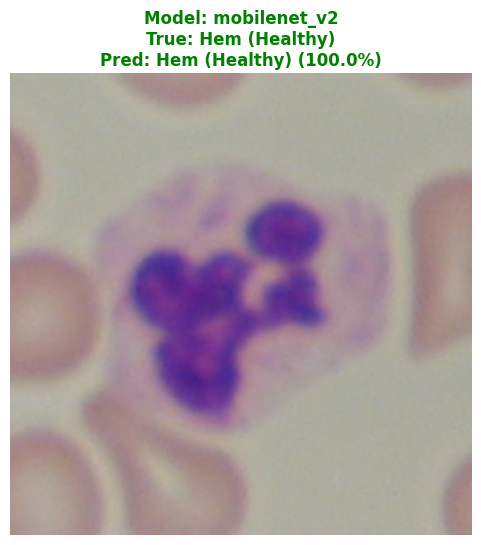

In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.models import get_model
from PIL import Image
import os

# ==========================================
# 1. CONFIGURATION (UPDATE THESE PATHS)
# ==========================================

# Path to the .pt file saved by your API
MODEL_PATH = "/content/drive/MyDrive/College/models/TEST-2.pt"

# Path to the image you want to test
IMAGE_PATH = "/content/drive/MyDrive/College/Datasets/fed_data/public_anchor/hem/allidb_Im132_0.tif"

# Classes (0: ALL/Leukemia, 1: Hem/Healthy)
CLASSES = ['ALL (Leukemia)', 'Hem (Healthy)']

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. ARCHITECTURE BUILDER (Must match API)
# ==========================================
def modify_last_layer(model, num_classes):
    """Reconstructs the final layer exactly as the API did."""
    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Linear):
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        updated = False
        for i in range(len(model.classifier) - 1, -1, -1):
            if isinstance(model.classifier[i], nn.Linear):
                in_features = model.classifier[i].in_features
                model.classifier[i] = nn.Linear(in_features, num_classes)
                updated = True
                break
        if not updated:
             model.classifier.add_module("final_fc", nn.Linear(1280, num_classes))
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        # SqueezeNet case
        final_conv = list(model.classifier.children())[1]
        if isinstance(final_conv, nn.Conv2d):
            new_conv = nn.Conv2d(final_conv.in_channels, num_classes, kernel_size=1)
            model.classifier[1] = new_conv
            model.num_classes = num_classes
    return model

# ==========================================
# 3. PREDICTION FUNCTION
# ==========================================
def predict_single_image(model_path, image_path):
    print(f"📂 Loading Model: {os.path.basename(model_path)}")
    print(f"🖼️  Loading Image: {os.path.basename(image_path)}")

    if not os.path.exists(model_path):
        print(f"❌ Error: Model file not found at {model_path}")
        return
    if not os.path.exists(image_path):
        print(f"❌ Error: Image file not found at {image_path}")
        return

    # --- A. Load Checkpoint Metadata ---
    try:
        checkpoint = torch.load(model_path, map_location=DEVICE)

        # Handle both formats (just in case)
        if isinstance(checkpoint, dict) and 'model_type' in checkpoint:
            model_name = checkpoint['model_type']
            state_dict = checkpoint['state_dict']
            print(f"   ℹ️  Detected Architecture: {model_name}")
        else:
            # Fallback if you have old models saved without metadata
            print("   ⚠️  Warning: Metadata missing. Assuming ResNet18.")
            model_name = "resnet18"
            state_dict = checkpoint

    except Exception as e:
        print(f"❌ Error reading checkpoint: {e}")
        return

    # --- B. Build Model ---
    try:
        model = get_model(model_name, weights=None)
        model = modify_last_layer(model, 2) # Force 2 classes
        model.to(DEVICE)

        # Load weights
        model.load_state_dict(state_dict)
        model.eval()
        print("   ✅ Model built and weights loaded.")
    except Exception as e:
        print(f"❌ Failed to build/load model: {e}")
        return

    # --- C. Prepare Image ---
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)

    # --- D. Predict ---
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_idx = outputs.argmax(dim=1).item()
        confidence = probs[0][pred_idx].item()

    pred_label = CLASSES[pred_idx]

    # --- E. Infer True Label from Folder Name (Optional) ---
    parent_folder = os.path.basename(os.path.dirname(image_path)).lower()
    true_label = "Unknown"
    color = "blue" # Default neutral

    if "all" in parent_folder:
        true_label = CLASSES[0]
        color = "green" if pred_idx == 0 else "red"
    elif "hem" in parent_folder:
        true_label = CLASSES[1]
        color = "green" if pred_idx == 1 else "red"

    # --- F. Visualize ---
    # Unnormalize for display
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    disp_img = inv_normalize(input_tensor[0].cpu()).permute(1, 2, 0).numpy()
    disp_img = np.clip(disp_img, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(disp_img)
    plt.title(f"Model: {model_name}\nTrue: {true_label}\nPred: {pred_label} ({confidence:.1%})",
              color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

# ==========================================
# 4. RUN
# ==========================================
predict_single_image(MODEL_PATH, IMAGE_PATH)

In [ ]:
# Kill any process running on port 8000
!fuser -k 8000/tcp

print("Attempted to kill processes on port 8000. Please re-run the FastAPI server cell now.")